#**3. Data Cleaning**

Notebook ini melakukan proses pembersihan data berdasarkan temuan dari tahap Data Understanding.

In [ ]:
#Load data
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Career Journey/Portofolio/1. retail sales analysis/data/raw/Sample - Superstore.csv', encoding='latin1')
df.head()



Mounted at /content/drive


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


####**3.1 Date Formatting**

`Order Date` dan `Ship Date` masih bertipe object, perlu dikonversi ke datetime supaya bisa
dipakai untuk analisis tren waktu di tahap EDA.

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

df[['Order Date', 'Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


#### **3.2 Data Type Correction**

Selain kolom tanggal, cek kolom lain yang tipenya kurang tepat,
`Postal Code` yang seharusnya bukan angka untuk dihitung (bersifat kategorikal/ID).

In [ ]:
df['Postal Code'] = df['Postal Code'].astype(str)
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


#### **3.3 Missing Values**

Cek missing value setelah konversi tipe data



In [ ]:
missing = df.isnull().sum()
missing[missing > 0]

,0


####**3.4 Duplikat Value**

In [ ]:
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

Jumlah baris duplikat: 0


#### **3.5 Outlier Check**

Cek outlier pada kolom numerik utama (`Sales`, `Profit`, `Discount`, `Quantity`) menggunakan
boxplot dan metode IQR.

#####3.5.1 Cek outlier dengan boxplot

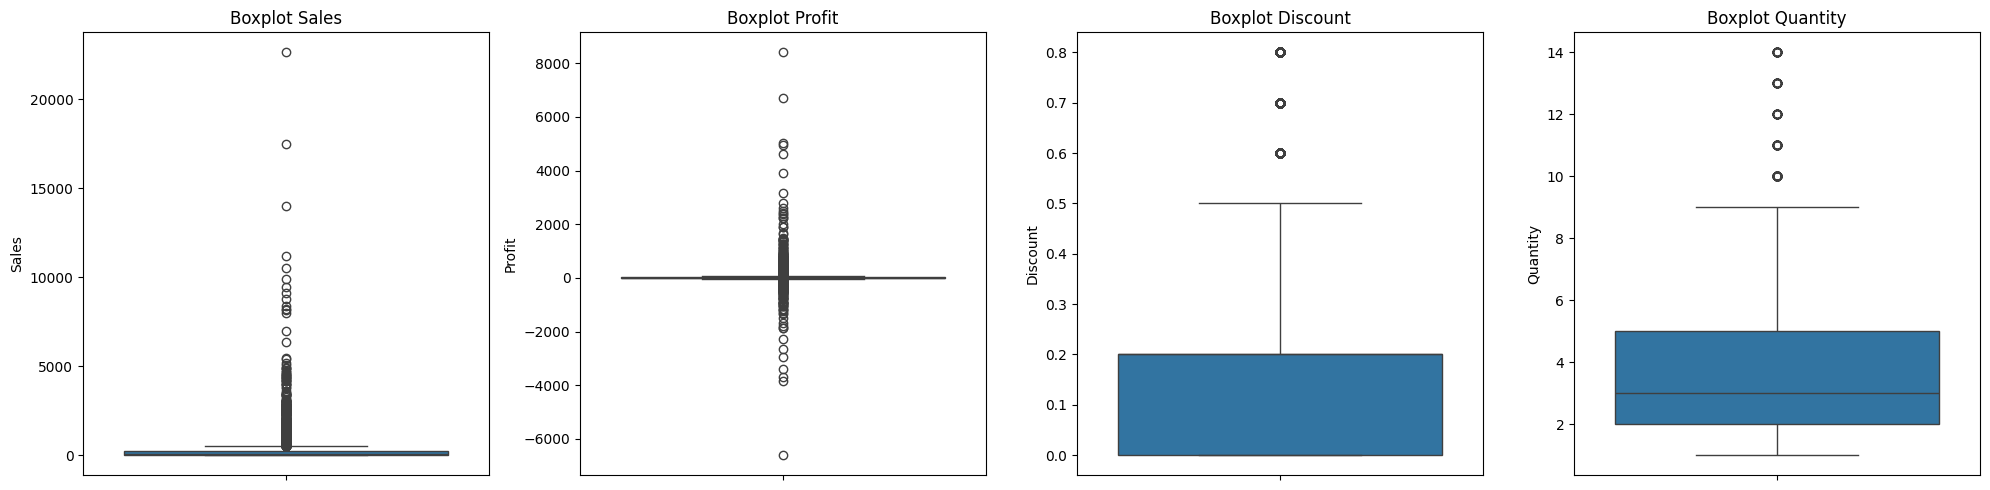

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
cols = ['Sales', 'Profit', 'Discount', 'Quantity']

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

#####3.5.2 Cek outlier dengan IQR

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return len(outliers), lower, upper

for col in cols:
    count, lower, upper = detect_outliers_iqr(df, col)
    print(f"{col}: {count} outliers (batas: {lower:.2f} - {upper:.2f})")

Sales: 1167 outliers (batas: -271.71 - 498.93)
Profit: 1881 outliers (batas: -39.72 - 70.82)
Discount: 856 outliers (batas: -0.30 - 0.50)
Quantity: 170 outliers (batas: -2.50 - 9.50)




Dari hasil boxplot dan IQR, keempat kolom (Sales, Profit, Discount, Quantity) sama-sama punya
outlier, dengan Profit paling banyak (1.881 baris), disusul Sales (1.167), Discount (856), dan
Quantity (170).

Tapi outlier ini bukan error, melainkan hal wajar di data retail:

- Sales tinggi biasanya dari pembelian produk mahal atau bulk order
- Profit yang outlier ekstrem (baik positif maupun negatif) justru menarik untuk dianalisis,
  karena outlier negatif kemungkinan berasal dari diskon yang kebesaran
- Discount di atas 50-80% memang jarang terjadi tapi valid, dan kemungkinan jadi penyebab profit
  yang minus
- Quantity tinggi wajar untuk transaksi Corporate/Home Office yang beli banyak sekaligus

Karena itu, outlier di sini tidak dihapus, karena informasinya justru dibutuhkan buat menjawab
business question soal hubungan Discount dan Profit di tahap EDA nanti.

#### **3.6 Membersihkan Karakter Quote pada Product Name**

Beberapa nama produk mengandung simbol petik dua (") untuk menunjukkan ukuran inch, yang
menyebabkan konflik saat proses import ke PostgreSQL.

In [17]:
df['Product Name'] = df['Product Name'].str.replace('"', '', regex=False)

#### **3.6 Save Cleaned Data**

In [21]:
import os

output_path = '/content/drive/MyDrive/Career Journey/Portofolio/1. retail sales analysis/data/cleaned/superstore_cleaned.csv'

os.makedirs(os.path.dirname(output_path), exist_ok=True)

df.to_csv(output_path, index=False)

print("Data cleaned berhasil disimpan!")
df.info()

Data cleaned berhasil disimpan!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   object        
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object   